In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
db_path = "../data/btc_prices.sqlite3"
conn = sqlite3.connect(db_path)

In [17]:
df = pd.read_sql_query("SELECT * FROM price_snapshots", conn)

In [18]:
df.head()

,id,asset,measurement_timestamp,observed_market_type,spot_price,perp_price,spot_microprice,perp_microprice,filtered_price,basis,recorded_at_ms,filtered_timestamp,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,observed_mid_price,observed_microprice
0,1,BTC,1774458045657,perp,NaN,71306.5,NaN,71306.858977,35238.866543,35238.866543,1774458045954,None,None,None,None,None,None,None,None
1,2,BTC,1774458045719,perp,NaN,71306.5,NaN,71306.834381,35455.008028,35455.008028,1774458045957,None,None,None,None,None,None,None,None
2,3,BTC,1774458045657,spot,71306.5,71306.5,71306.858977,71306.834381,69709.376791,1678.771777,1774458045969,None,None,None,None,None,None,None,None
3,4,BTC,1774458045719,spot,71306.5,71306.5,71306.834381,71306.834381,70513.206148,919.886508,1774458045971,None,None,None,None,None,None,None,None
4,5,BTC,1774458045855,perp,71306.5,71306.5,71306.834381,71306.787590,70508.053688,869.028456,1774458046096,None,None,None,None,None,None,None,None


In [19]:
df["measurement_timestamp"] = pd.to_datetime(df["measurement_timestamp"], unit="ms")
df["recorded_at"] = pd.to_datetime(df["recorded_at_ms"], unit="ms")

In [20]:
df.head()

,id,asset,measurement_timestamp,observed_market_type,spot_price,perp_price,spot_microprice,perp_microprice,filtered_price,basis,recorded_at_ms,filtered_timestamp,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,observed_mid_price,observed_microprice,recorded_at
0,1,BTC,2026-03-25 17:00:45.657,perp,NaN,71306.5,NaN,71306.858977,35238.866543,35238.866543,1774458045954,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.954
1,2,BTC,2026-03-25 17:00:45.719,perp,NaN,71306.5,NaN,71306.834381,35455.008028,35455.008028,1774458045957,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.957
2,3,BTC,2026-03-25 17:00:45.657,spot,71306.5,71306.5,71306.858977,71306.834381,69709.376791,1678.771777,1774458045969,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.969
3,4,BTC,2026-03-25 17:00:45.719,spot,71306.5,71306.5,71306.834381,71306.834381,70513.206148,919.886508,1774458045971,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.971
4,5,BTC,2026-03-25 17:00:45.855,perp,71306.5,71306.5,71306.834381,71306.787590,70508.053688,869.028456,1774458046096,None,None,None,None,None,None,None,None,2026-03-25 17:00:46.096


In [21]:
df = (
      df.drop(columns=["id", "asset"])
        .assign(measurement_timestamp=lambda x: pd.to_datetime(x["measurement_timestamp"], unit="ms"))
        .set_index("measurement_timestamp")
        .sort_index()
  )

In [22]:
df.head()

,observed_market_type,spot_price,perp_price,spot_microprice,perp_microprice,filtered_price,basis,recorded_at_ms,filtered_timestamp,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,observed_mid_price,observed_microprice,recorded_at
measurement_timestamp,,,,,,,,,,,,,,,,,
2026-03-25 17:00:45.657,perp,NaN,71306.5,NaN,71306.858977,35238.866543,35238.866543,1774458045954,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.954
2026-03-25 17:00:45.657,spot,71306.5,71306.5,71306.858977,71306.834381,69709.376791,1678.771777,1774458045969,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.969
2026-03-25 17:00:45.719,perp,NaN,71306.5,NaN,71306.834381,35455.008028,35455.008028,1774458045957,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.957
2026-03-25 17:00:45.719,spot,71306.5,71306.5,71306.834381,71306.834381,70513.206148,919.886508,1774458045971,None,None,None,None,None,None,None,None,2026-03-25 17:00:45.971
2026-03-25 17:00:45.855,perp,71306.5,71306.5,71306.834381,71306.787590,70508.053688,869.028456,1774458046096,None,None,None,None,None,None,None,None,2026-03-25 17:00:46.096


In [23]:
df = df.iloc[60:]

In [24]:
df.head(20)

,observed_market_type,spot_price,perp_price,spot_microprice,perp_microprice,filtered_price,basis,recorded_at_ms,filtered_timestamp,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,observed_mid_price,observed_microprice,recorded_at
measurement_timestamp,,,,,,,,,,,,,,,,,
2026-03-25 17:00:49.610,spot,71306.5,71306.5,71306.175392,71306.178380,71304.632607,5.276773,1774458050055,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.055
2026-03-25 17:00:49.610,perp,71306.5,71306.5,71306.148123,71306.175392,71304.122001,3.067549,1774458050062,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.062
2026-03-25 17:00:49.727,perp,71306.5,71306.5,71306.148123,71306.148123,71304.005817,2.875466,1774458050064,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.064
2026-03-25 17:00:49.727,spot,71306.5,71306.5,71306.148123,71306.178380,71304.947522,5.208763,1774458050056,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.056
2026-03-25 17:00:50.066,perp,71306.5,71306.5,71306.175238,71306.175238,71304.460172,2.373068,1774458050253,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.253
2026-03-25 17:00:50.066,spot,71306.5,71306.5,71306.175238,71306.148123,71304.561202,2.557105,1774458050237,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.237
2026-03-25 17:00:50.130,perp,71306.5,71306.5,71306.175238,71306.175087,71304.388528,2.259776,1774458050302,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.302
2026-03-25 17:00:50.130,spot,71306.5,71306.5,71306.175087,71306.175087,71304.857462,1.992618,1774458050306,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.306
2026-03-25 17:00:50.190,spot,71306.5,71306.5,71306.174936,71306.175087,71305.166714,1.841864,1774458050335,None,None,None,None,None,None,None,None,2026-03-25 17:00:50.335


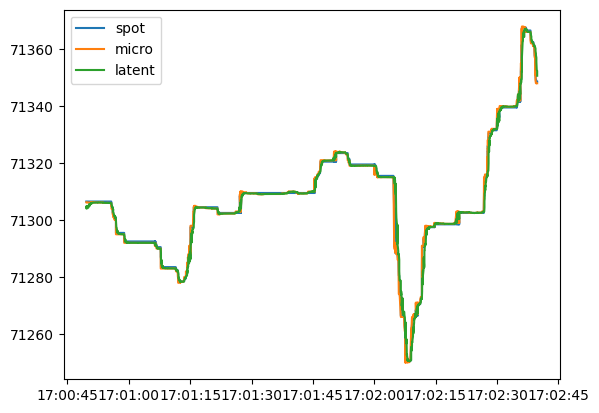

In [26]:
plt.plot(df.spot_price, label="spot")
plt.plot(df.spot_microprice, label="micro")
plt.plot(df.filtered_price, label="latent")
plt.legend()

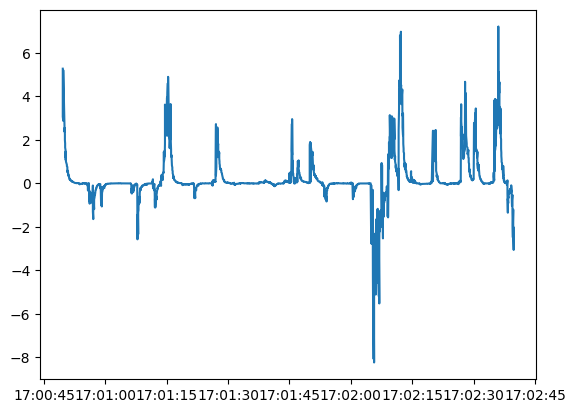

In [27]:
plt.plot(df.basis)

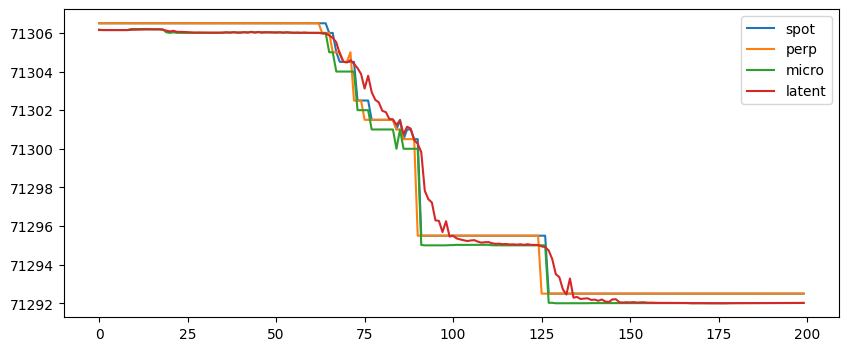

In [33]:
sample = df.iloc[50:250].copy().reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(sample["spot_price"], label="spot")
plt.plot(sample["perp_price"], label="perp")
plt.plot(sample["spot_microprice"], label="micro")
plt.plot(sample["filtered_price"], label="latent")

plt.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.legend()
plt.show()

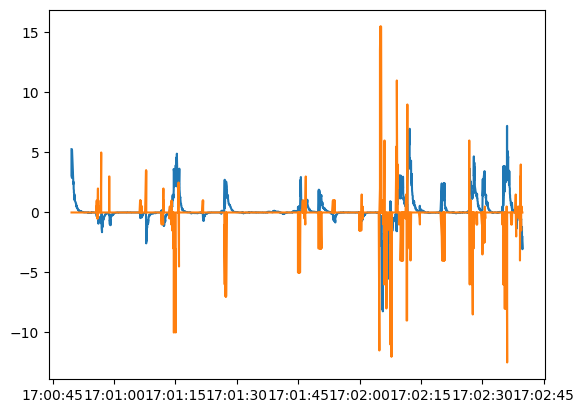

In [34]:
plt.plot(df.basis)
plt.plot((df.spot_price - df.perp_price))

## Now lets test prediction using latent